# 02 — Hiểu dữ liệu hành vi khách hàng theo thời gian

Notebook này thực hiện **data understanding** và **EDA** cho UCI Online Retail II. Mục tiêu là hiểu dữ liệu giao dịch, xác định cleaning phù hợp với bài toán purchase-behavior forecasting, và minh họa cách chuyển từ transaction lines sang customer-week observations.

Giới hạn của notebook:

- chỉ đọc workbook raw đã khóa tại `datasets/customer/online_retail_II.xlsx`;
- không sửa hoặc ghi đè workbook raw;
- không tạo train/validation/test sequences cuối cùng;
- không fit scaler, không tính class weight và không train PyTorch/Keras RNN.


## Thiết lập

`SEED = 42` được giữ nhất quán với experiment contract. Toàn bộ figures tái sử dụng được lưu vào `results/figures/customer_eda/`.


In [1]:
import gc
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_PATH = PROJECT_ROOT / "datasets" / "customer" / "online_retail_II.xlsx"
FIGURE_DIR = PROJECT_ROOT / "results" / "figures" / "customer_eda"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

assert RAW_PATH.is_file(), f"Không tìm thấy raw workbook: {RAW_PATH}"
print(f"Python executable: {sys.executable}")
print(f"Raw workbook: {RAW_PATH}")
print(f"Figure directory: {FIGURE_DIR}")

Python executable: C:\Users\anhca\anaconda3\envs\rnn312\python.exe
Raw workbook: C:\DATA\assign\A06\datasets\customer\online_retail_II.xlsx
Figure directory: C:\DATA\assign\A06\results\figures\customer_eda


## 1. Giới thiệu dataset

**Online Retail II** ghi lại các transaction lines của một nhà bán lẻ trực tuyến tại Anh trong khoảng **01/12/2009–09/12/2011**. Mỗi dòng không nhất thiết là một đơn hàng: một invoice có thể chứa nhiều sản phẩm và vì vậy xuất hiện trên nhiều dòng.

Các trường chính mô tả invoice, sản phẩm, số lượng, thời điểm, đơn giá, khách hàng và quốc gia. Dữ liệu phù hợp với phân tích hành vi theo thời gian vì mỗi giao dịch có `InvoiceDate` và có thể liên kết các lần mua của cùng `CustomerID`.

Bài toán RNN ở milestone sau sẽ là:

> Từ 8 tuần hành vi gần nhất của một khách hàng, dự đoán khách hàng có mua trong tuần kế tiếp hay không.

Đây là binary classification ở mức **customer-week**, không phải dự đoán từng transaction line.


## 2. Đọc và xác thực các raw sheets

Ta hỏi workbook về sheet names trước, đọc từng sheet riêng, ghi lại shape/columns/dtypes, rồi chỉ `concat` sau khi xác nhận schema giống nhau. Không giả định tên cột theo tài liệu phiên bản mới.


In [ ]:
excel_file = pd.ExcelFile(RAW_PATH)
sheet_names = excel_file.sheet_names
print("Sheet names:", sheet_names)

sheet_frames = {}
sheet_records = []
sheet_dtypes = {}

for sheet_name in sheet_names:
    frame = pd.read_excel(RAW_PATH, sheet_name=sheet_name)
    sheet_frames[sheet_name] = frame
    sheet_records.append(
        {
            "sheet": sheet_name,
            "rows": len(frame),
            "columns": frame.shape[1],
            "column_names": ", ".join(map(str, frame.columns)),
        }
    )
    sheet_dtypes[sheet_name] = frame.dtypes.astype(str)

sheet_summary = pd.DataFrame(sheet_records)
dtype_summary = pd.DataFrame(sheet_dtypes).T
display(sheet_summary)
display(dtype_summary)

schemas = [tuple(frame.columns) for frame in sheet_frames.values()]
assert all(
    schema == schemas[0] for schema in schemas
), "Schemas giữa các sheets không tương thích"

raw_df = pd.concat(sheet_frames.values(), ignore_index=True)
print(f"Schema tương thích: {list(raw_df.columns)}")
print(f"Combined raw shape: {raw_df.shape}")
display(raw_df.head(3))

del sheet_frames
_ = gc.collect()

Sheet names: ['Year 2009-2010', 'Year 2010-2011']


,sheet,rows,columns,column_names
0,Year 2009-2010,525461,8,"Invoice, StockCode, Description, Quantity, Inv..."
1,Year 2010-2011,541910,8,"Invoice, StockCode, Description, Quantity, Inv..."


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
Year 2009-2010,object,object,object,int64,datetime64[us],float64,float64,str
Year 2010-2011,object,object,object,int64,datetime64[us],float64,float64,str


Schema tương thích: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
Combined raw shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom


Hai sheets có cùng 8 raw columns và lần lượt 525.461 và 541.910 dòng, nên có thể ghép theo hàng. Tổng cộng là **1.067.371 transaction lines**.

Workbook dùng tên cột lịch sử. Ta chuẩn hóa **chỉ trong DataFrame memory**:

- `Invoice → InvoiceNo`
- `Price → UnitPrice`
- `Customer ID → CustomerID`

File `.xlsx` trên đĩa không bị thay đổi.


In [ ]:
expected_aliases = {
    "Invoice": "InvoiceNo",
    "Price": "UnitPrice",
    "Customer ID": "CustomerID",
}
rename_map = {
    raw_name: normalized_name
    for raw_name, normalized_name in expected_aliases.items()
    if raw_name in raw_df.columns
}

data_df = raw_df.rename(columns=rename_map).copy()
required_columns = {
    "InvoiceNo",
    "StockCode",
    "Description",
    "Quantity",
    "InvoiceDate",
    "UnitPrice",
    "CustomerID",
    "Country",
}
assert required_columns.issubset(data_df.columns)

print("Column normalization thực tế:", rename_map)
print("Columns sau normalization:", list(data_df.columns))

Column normalization thực tế: {'Invoice': 'InvoiceNo', 'Price': 'UnitPrice', 'Customer ID': 'CustomerID'}
Columns sau normalization: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


## 3. Data integrity audit

Audit bên dưới đo shape, exact duplicates, missing values, ngày lỗi, phân phối `Quantity`/`UnitPrice`, quy mô khách hàng/invoice/quốc gia và date range. Ta chưa lọc dữ liệu trong bước này để các vấn đề không bị che mất.


In [ ]:
data_df["InvoiceDate"] = pd.to_datetime(data_df["InvoiceDate"], errors="coerce")
data_df["CustomerID"] = pd.to_numeric(data_df["CustomerID"], errors="coerce")
data_df["Quantity"] = pd.to_numeric(data_df["Quantity"], errors="coerce")
data_df["UnitPrice"] = pd.to_numeric(data_df["UnitPrice"], errors="coerce")

invoice_text = data_df["InvoiceNo"].astype("string").str.strip()
is_cancellation = invoice_text.str.upper().str.startswith("C", na=False)

audit_overview = pd.Series(
    {
        "rows": len(data_df),
        "columns": data_df.shape[1],
        "exact_duplicate_rows": int(data_df.duplicated().sum()),
        "invalid_dates": int(data_df["InvoiceDate"].isna().sum()),
        "missing_customer_id": int(data_df["CustomerID"].isna().sum()),
        "unique_countries": int(data_df["Country"].nunique(dropna=True)),
        "unique_customers": int(data_df["CustomerID"].nunique(dropna=True)),
        "unique_invoices": int(data_df["InvoiceNo"].nunique(dropna=True)),
        "date_min": data_df["InvoiceDate"].min(),
        "date_max": data_df["InvoiceDate"].max(),
    },
    name="value",
)
missing_summary = (
    data_df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_pct=lambda table: 100 * table["missing_count"] / len(data_df))
)

display(audit_overview.to_frame())
display(missing_summary)

,value
rows,1067371
columns,8
exact_duplicate_rows,34335
invalid_dates,0
missing_customer_id,243007
unique_countries,43
unique_customers,5942
unique_invoices,53628
date_min,2009-12-01 07:45:00
date_max,2011-12-09 12:50:00


,missing_count,missing_pct
InvoiceNo,0,0.00
StockCode,0,0.00
Description,4382,0.41
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,243007,22.77
Country,0,0.00


In [5]:
selected_percentiles = [0.01, 0.25, 0.50, 0.75, 0.99]
distribution_summary = data_df[["Quantity", "UnitPrice"]].describe(
    percentiles=selected_percentiles
)
display(distribution_summary)

print("Quantity < 0:", int((data_df["Quantity"] < 0).sum()))
print("Quantity = 0:", int((data_df["Quantity"] == 0).sum()))
print("UnitPrice <= 0:", int((data_df["UnitPrice"] <= 0).sum()))

,Quantity,UnitPrice
count,"1,067,371.00","1,067,371.00"
mean,9.94,4.65
std,172.71,123.55
min,"-80,995.00","-53,594.36"
1%,-3.00,0.21
25%,1.00,1.25
50%,3.00,2.10
75%,10.00,4.15
99%,100.00,18.00
max,"80,995.00","38,970.00"


Quantity < 0: 22950
Quantity = 0: 0
UnitPrice <= 0: 6207


**Nhận xét integrity thực tế**

- Có **34.335 exact duplicate rows**. Vì `Quantity` đã biểu diễn số lượng, giữ exact duplicates sẽ có nguy cơ đếm lặp doanh thu và hành vi; modeling DataFrame sẽ loại chúng nhưng audit raw vẫn giữ nguyên.
- `CustomerID` thiếu ở **243.007 dòng**; các dòng này không thể gắn thành sequence của một khách hàng cụ thể.
- `Description` thiếu ở **4.382 dòng**, nhưng không phải điều kiện quyết định vì feature production dùng `StockCode`, số lượng, invoice và revenue.
- Không có `InvoiceDate` lỗi/thiếu sau parsing.
- `Quantity` và `UnitPrice` có extreme values và giá trị âm/không dương. Vì vậy mean đơn thuần dễ bị chi phối; notebook hiển thị percentiles và dùng cleaning theo ý nghĩa mua hàng.
- Date range raw là **2009-12-01 07:45:00 đến 2011-12-09 12:50:00**; tháng đầu và tháng cuối là các khoảng quan sát không đầy đủ.


## 4. Cancellation invoices

Ta xác định convention từ chính dữ liệu: invoice bị hủy có mã bắt đầu bằng chữ `C` (không phân biệt hoa/thường). Cancellation thường đi kèm `Quantity < 0`, biểu thị đảo ngược giao dịch trước đó. Chúng mang thông tin nghiệp vụ về return/cancellation, nhưng không phải một lần **purchase dương** cho target “có mua tuần sau”.

Vì vậy ta đếm và quan sát chúng **trước khi lọc**, thay vì xóa im lặng.


In [ ]:
cancellation_summary = pd.Series(
    {
        "cancellation_lines": int(is_cancellation.sum()),
        "unique_cancellation_invoices": int(
            data_df.loc[is_cancellation, "InvoiceNo"].nunique(dropna=True)
        ),
        "cancellation_lines_with_negative_quantity": int(
            (is_cancellation & (data_df["Quantity"] < 0)).sum()
        ),
        "all_negative_quantity_lines": int((data_df["Quantity"] < 0).sum()),
    },
    name="count",
)
display(cancellation_summary.to_frame())
display(
    data_df.loc[
        is_cancellation,
        [
            "InvoiceNo",
            "StockCode",
            "Description",
            "Quantity",
            "UnitPrice",
            "InvoiceDate",
        ],
    ].head(5)
)

,count
cancellation_lines,19494
unique_cancellation_invoices,8292
cancellation_lines_with_negative_quantity,19493
all_negative_quantity_lines,22950


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,InvoiceDate
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2.95,2009-12-01 10:33:00
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,1.65,2009-12-01 10:33:00
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,4.25,2009-12-01 10:33:00
181,C489449,21896,POTTING SHED TWINE,-6,2.10,2009-12-01 10:33:00
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2.95,2009-12-01 10:33:00


Kết quả có **19.494 cancellation lines** thuộc **8.292 cancellation invoices**; 19.493 dòng trong số đó có `Quantity < 0`. Việc kiểm tra cả prefix và dấu của `Quantity` giúp phát hiện một ngoại lệ thay vì giả định hai quy tắc hoàn toàn tương đương.


## 5. Cleaning rules cho purchase-behavior forecasting

Modeling DataFrame áp dụng các quy tắc sau trong memory:

1. bỏ exact duplicate rows để tránh đếm lặp cùng transaction line;
2. giữ `CustomerID` numeric, dương và nguyên để có thể tạo lịch sử theo khách hàng;
3. giữ `InvoiceDate` hợp lệ;
4. loại invoice có prefix `C` vì đó là cancellation, không phải purchase dương;
5. yêu cầu `Quantity > 0`;
6. yêu cầu `UnitPrice > 0`.

Các quy tắc này phục vụ task dự đoán **purchase activity**. Một bài toán riêng về return/cancellation có thể cần giữ các dòng âm, nhưng đó không phải target của A06.


In [ ]:
customer_is_integer = data_df["CustomerID"].mod(1).eq(0).fillna(False)
valid_customer = (
    data_df["CustomerID"].notna() & data_df["CustomerID"].gt(0) & customer_is_integer
)
valid_date = data_df["InvoiceDate"].notna()
positive_quantity = data_df["Quantity"].gt(0)
positive_price = data_df["UnitPrice"].gt(0)

deduplicated_df = data_df.drop_duplicates().copy()
dedup_invoice_text = deduplicated_df["InvoiceNo"].astype("string").str.strip()
dedup_is_cancellation = dedup_invoice_text.str.upper().str.startswith("C", na=False)
dedup_customer_integer = deduplicated_df["CustomerID"].mod(1).eq(0).fillna(False)

clean_mask = (
    deduplicated_df["CustomerID"].notna()
    & deduplicated_df["CustomerID"].gt(0)
    & dedup_customer_integer
    & deduplicated_df["InvoiceDate"].notna()
    & ~dedup_is_cancellation
    & deduplicated_df["Quantity"].gt(0)
    & deduplicated_df["UnitPrice"].gt(0)
)

cleaning_checks = pd.DataFrame(
    {
        "rule": [
            "raw rows",
            "exact duplicates removed",
            "invalid/missing CustomerID",
            "invalid InvoiceDate",
            "cancellation prefix C",
            "Quantity <= 0",
            "UnitPrice <= 0",
            "final cleaned rows",
        ],
        "count": [
            len(data_df),
            int(data_df.duplicated().sum()),
            int((~valid_customer).sum()),
            int((~valid_date).sum()),
            int(is_cancellation.sum()),
            int((~positive_quantity).sum()),
            int((~positive_price).sum()),
            int(clean_mask.sum()),
        ],
    }
)

clean_df = deduplicated_df.loc[clean_mask].copy()
clean_df["InvoiceNo"] = clean_df["InvoiceNo"].astype("string").str.strip()
clean_df["CustomerID"] = clean_df["CustomerID"].astype("int64")

display(cleaning_checks)
print(f"Cleaned modeling shape: {clean_df.shape}")
print(f"Cleaned customers: {clean_df['CustomerID'].nunique():,}")
print(f"Cleaned invoices: {clean_df['InvoiceNo'].nunique():,}")
print(
    "Cleaned date range:",
    clean_df["InvoiceDate"].min(),
    "->",
    clean_df["InvoiceDate"].max(),
)

del raw_df, data_df, deduplicated_df
_ = gc.collect()

,rule,count
0,raw rows,1067371
1,exact duplicates removed,34335
2,invalid/missing CustomerID,243007
3,invalid InvoiceDate,0
4,cancellation prefix C,19494
5,Quantity <= 0,22950
6,UnitPrice <= 0,6207
7,final cleaned rows,779425


Cleaned modeling shape: (779425, 8)
Cleaned customers: 5,878
Cleaned invoices: 36,969
Cleaned date range: 2009-12-01 07:45:00 -> 2011-12-09 12:50:00


Các failure counts trong bảng có thể chồng lấp nhau, nên không được cộng trực tiếp để suy ra số dòng cuối. `final cleaned rows` được tính bằng một combined mask duy nhất sau khi bỏ exact duplicates.

## 6. Tạo `Revenue`

Với các purchase lines hợp lệ:

$$
\text{Revenue} = \text{Quantity} \times \text{UnitPrice}
$$

Đây là giá trị ở mức invoice line. Khi tổng hợp customer-week, `total_spent` là tổng `Revenue` của các dòng trong tuần đó.


In [ ]:
clean_df["Revenue"] = clean_df["Quantity"] * clean_df["UnitPrice"]
assert clean_df["Revenue"].gt(0).all()

display(
    clean_df[
        [
            "InvoiceNo",
            "StockCode",
            "Quantity",
            "UnitPrice",
            "Revenue",
            "InvoiceDate",
            "CustomerID",
        ]
    ].head(5)
)
print(f"Tổng Revenue trong cleaned EDA data: {clean_df['Revenue'].sum():,.2f}")

,InvoiceNo,StockCode,Quantity,UnitPrice,Revenue,InvoiceDate,CustomerID
0,489434,85048,12,6.95,83.40,2009-12-01 07:45:00,13085
1,489434,79323P,12,6.75,81.00,2009-12-01 07:45:00,13085
2,489434,79323W,12,6.75,81.00,2009-12-01 07:45:00,13085
3,489434,22041,48,2.10,100.80,2009-12-01 07:45:00,13085
4,489434,21232,24,1.25,30.00,2009-12-01 07:45:00,13085


Tổng Revenue trong cleaned EDA data: 17,374,804.27


## 7. Phân tích hành vi khách hàng

### 7.1 Orders, revenue và active customers theo tháng

“Order” được đếm bằng số `InvoiceNo` duy nhất, không phải số invoice lines. Ba đường thời gian dùng chung cleaned DataFrame nhưng đo ba khía cạnh khác nhau: lượng orders, giá trị mua hàng và độ rộng của customer base hoạt động.


,transaction_lines,order_count,revenue,active_customers
Month,,,,
2009-12-01,30272,1512,"683,504.01",955
2010-01-01,21458,1011,"555,802.67",720
2010-02-01,23040,1104,"504,558.96",772
2010-03-01,31782,1524,"696,978.47",1057


,transaction_lines,order_count,revenue,active_customers
Month,,,,
2011-09-01,39669,1755,"950,690.20",1266
2011-10-01,48793,1929,"1,035,642.45",1364
2011-11-01,63168,2657,"1,156,205.61",1664
2011-12-01,17027,778,"517,208.44",615


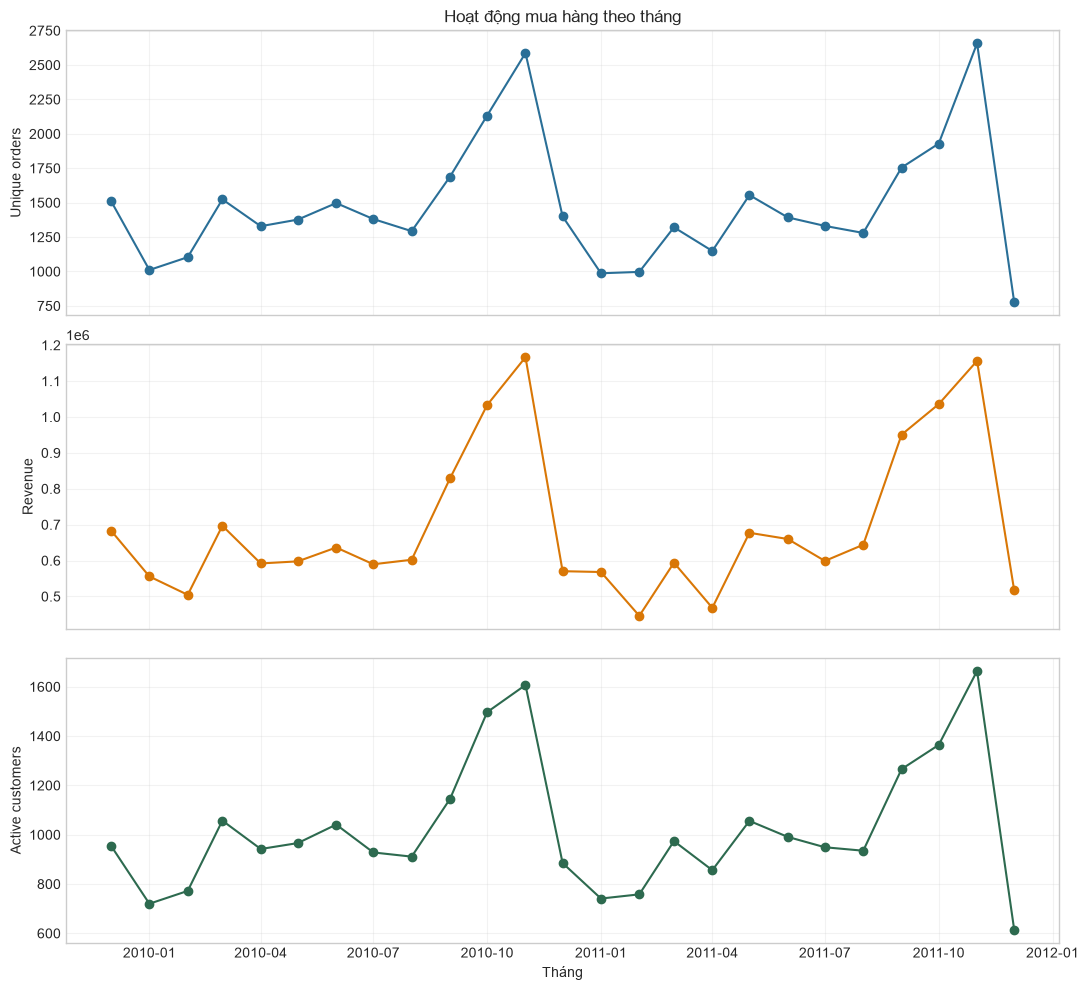

Đã lưu: C:\DATA\assign\A06\results\figures\customer_eda\monthly_activity.png


In [ ]:
clean_df["Month"] = clean_df["InvoiceDate"].dt.to_period("M").dt.to_timestamp()
monthly_activity = (
    clean_df.groupby("Month", observed=True)
    .agg(
        transaction_lines=("InvoiceNo", "size"),
        order_count=("InvoiceNo", "nunique"),
        revenue=("Revenue", "sum"),
        active_customers=("CustomerID", "nunique"),
    )
    .sort_index()
)

display(monthly_activity.head(4))
display(monthly_activity.tail(4))

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
axes[0].plot(
    monthly_activity.index, monthly_activity["order_count"], color="#2A6F97", marker="o"
)
axes[0].set_ylabel("Unique orders")
axes[0].set_title("Hoạt động mua hàng theo tháng")

axes[1].plot(
    monthly_activity.index, monthly_activity["revenue"], color="#D97706", marker="o"
)
axes[1].set_ylabel("Revenue")

axes[2].plot(
    monthly_activity.index,
    monthly_activity["active_customers"],
    color="#2D6A4F",
    marker="o",
)
axes[2].set_ylabel("Active customers")
axes[2].set_xlabel("Tháng")

for axis in axes:
    axis.grid(alpha=0.25)

fig.tight_layout()
output_path = FIGURE_DIR / "monthly_activity.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Đã lưu: {output_path}")

**Nhận xét:** ba series thay đổi cùng chiều ở nhiều giai đoạn nhưng không hoàn toàn trùng nhau: nhiều orders không nhất thiết đồng nghĩa revenue tăng tỷ lệ thuận. Hoạt động mạnh vào các giai đoạn cuối năm cho thấy seasonality có thể quan trọng. Tuy nhiên tháng 12/2009 và 12/2011 là partial months, vì vậy không nên so sánh trực tiếp chúng với tháng đầy đủ.

### 7.2 Phân phối spending, purchase frequency và order count

Ta tóm tắt mỗi khách hàng bằng tổng spending, số orders duy nhất và số active weeks. `active_weeks` là một cách nhìn purchase frequency phù hợp với unit thời gian của task.


,total_spent,order_count,active_weeks
count,"5,878.00","5,878.00","5,878.00"
mean,"2,955.90",6.29,5.34
std,"14,440.85",13.01,7.63
min,2.95,1.00,1.00
25%,342.28,1.00,1.00
50%,867.74,3.00,3.00
75%,"2,248.30",7.00,6.00
90%,"5,465.74",13.00,12.00
99%,"29,205.90",46.00,36.23
max,"580,987.04",398.00,102.00


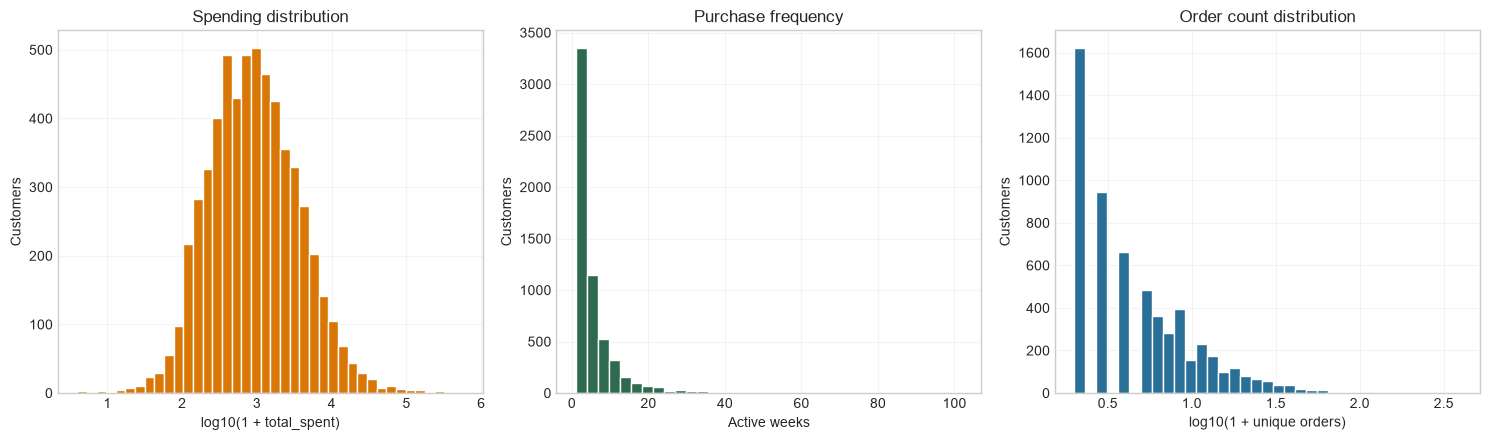

Đã lưu: C:\DATA\assign\A06\results\figures\customer_eda\customer_distributions.png


In [ ]:
clean_df["WeekStart"] = clean_df["InvoiceDate"].dt.to_period("W-SUN").dt.start_time
customer_summary = clean_df.groupby("CustomerID", observed=True).agg(
    total_spent=("Revenue", "sum"),
    order_count=("InvoiceNo", "nunique"),
    active_weeks=("WeekStart", "nunique"),
)

display(customer_summary.describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.99]))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].hist(
    np.log10(1 + customer_summary["total_spent"]),
    bins=40,
    color="#D97706",
    edgecolor="white",
)
axes[0].set(
    title="Spending distribution", xlabel="log10(1 + total_spent)", ylabel="Customers"
)

axes[1].hist(
    customer_summary["active_weeks"], bins=35, color="#2D6A4F", edgecolor="white"
)
axes[1].set(title="Purchase frequency", xlabel="Active weeks", ylabel="Customers")

axes[2].hist(
    np.log10(1 + customer_summary["order_count"]),
    bins=35,
    color="#2A6F97",
    edgecolor="white",
)
axes[2].set(
    title="Order count distribution",
    xlabel="log10(1 + unique orders)",
    ylabel="Customers",
)

for axis in axes:
    axis.grid(alpha=0.2)

fig.tight_layout()
output_path = FIGURE_DIR / "customer_distributions.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Đã lưu: {output_path}")

**Nhận xét:** các phân phối lệch phải rõ rệt—đa số khách hàng mua ít lần, trong khi một nhóm nhỏ mua thường xuyên và chi tiêu rất lớn. Vì vậy biểu đồ spending và order count dùng `log10(1 + value)` để phần thân phân phối vẫn đọc được; đây chỉ là cách vẽ EDA, không phải feature transformation đã khóa cho model.

### 7.3 Quốc gia

Ta so sánh top 10 quốc gia theo revenue, đồng thời xem số active customers. Hai chỉ số giúp tránh kết luận chỉ từ tổng tiền.


,revenue,order_count,active_customers
Country,,,
United Kingdom,"14,389,234.92",33541,5350
EIRE,"616,570.54",567,5
Netherlands,"554,038.09",228,22
Germany,"425,019.71",789,107
France,"348,768.96",614,95
Australia,"169,283.46",95,15
Spain,"108,332.49",154,41
Switzerland,"100,061.94",90,22
Sweden,"91,515.82",104,19


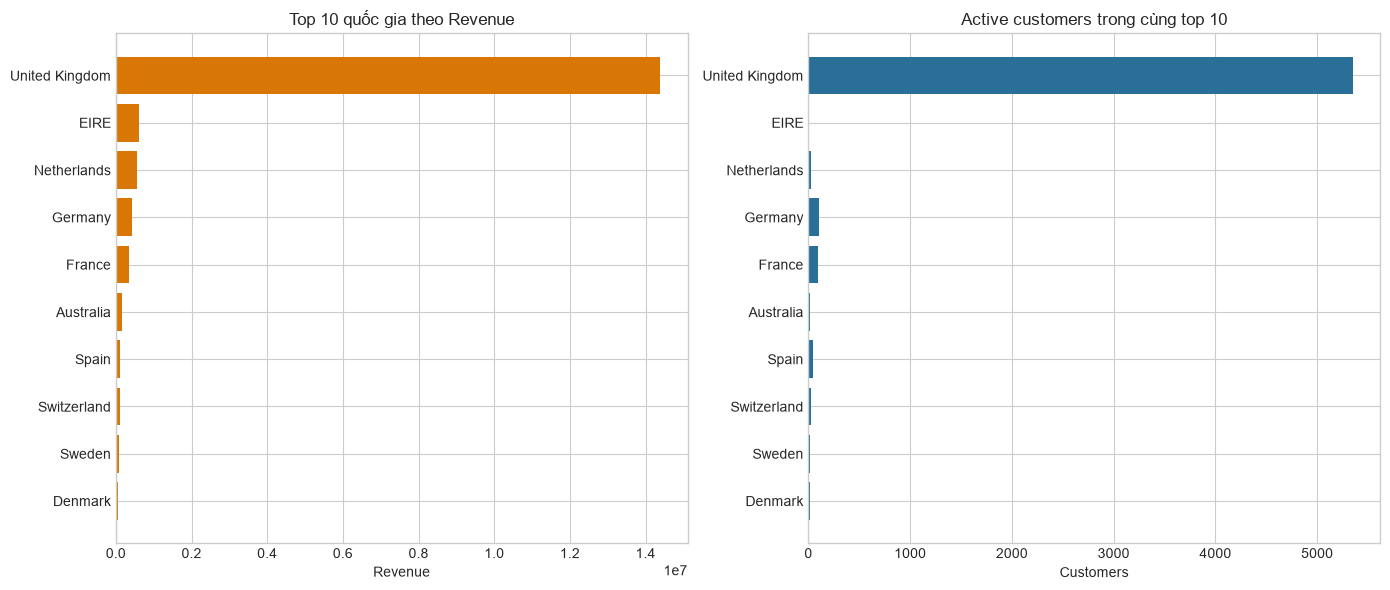

Đã lưu: C:\DATA\assign\A06\results\figures\customer_eda\top_countries.png


In [11]:
country_summary = (
    clean_df.groupby("Country", observed=True)
    .agg(
        revenue=("Revenue", "sum"),
        order_count=("InvoiceNo", "nunique"),
        active_customers=("CustomerID", "nunique"),
    )
    .sort_values("revenue", ascending=False)
)
top_countries = country_summary.head(10).sort_values("revenue")
display(country_summary.head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(top_countries.index, top_countries["revenue"], color="#D97706")
axes[0].set(title="Top 10 quốc gia theo Revenue", xlabel="Revenue")

axes[1].barh(top_countries.index, top_countries["active_customers"], color="#2A6F97")
axes[1].set(title="Active customers trong cùng top 10", xlabel="Customers")

fig.tight_layout()
output_path = FIGURE_DIR / "top_countries.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Đã lưu: {output_path}")

**Nhận xét:** `United Kingdom` chiếm ưu thế rất lớn về revenue và số khách hàng, phù hợp với bối cảnh nhà bán lẻ tại Anh. Các quốc gia khác vẫn có customer behavior đáng kể nhưng quy mô không đồng đều; model sau này không dùng `Country` trong bộ 5 features đã khóa.


## 8. Khái niệm customer-week aggregation

Một row trong bảng tuần biểu diễn hành vi của **một khách hàng trong một tuần hoạt động**. Quy ước tuần là thứ Hai–Chủ Nhật (`W-SUN`, nên `WeekStart` là thứ Hai).

Candidate features:

- `total_spent`: tổng `Revenue`;
- `total_quantity`: tổng số lượng mua;
- `order_count`: số `InvoiceNo` duy nhất;
- `unique_products`: số `StockCode` duy nhất;
- `active_flag = 1` nếu có ít nhất một purchase hợp lệ.

Điểm quan trọng: nhiều invoice lines cùng `InvoiceNo` vẫn chỉ là **một order**.


In [12]:
customer_week_active = (
    clean_df.groupby(["CustomerID", "WeekStart"], observed=True)
    .agg(
        total_spent=("Revenue", "sum"),
        total_quantity=("Quantity", "sum"),
        order_count=("InvoiceNo", "nunique"),
        unique_products=("StockCode", "nunique"),
    )
    .reset_index()
)
customer_week_active["active_flag"] = np.int8(1)

assert customer_week_active["order_count"].ge(1).all()
assert customer_week_active["active_flag"].eq(1).all()

print(f"Active customer-week rows: {len(customer_week_active):,}")
print(
    "WeekStart range:",
    customer_week_active["WeekStart"].min().date(),
    "->",
    customer_week_active["WeekStart"].max().date(),
)
display(customer_week_active.head(8))

Active customer-week rows: 31,362
WeekStart range: 2009-11-30 -> 2011-12-05


,CustomerID,WeekStart,total_spent,total_quantity,order_count,unique_products,active_flag
0,12346,2009-12-14,113.50,26,5,2,1
1,12346,2010-01-04,45.00,10,2,1,1
2,12346,2010-01-11,22.50,5,1,1,1
3,12346,2010-01-18,22.50,5,1,1,1
4,12346,2010-03-01,27.05,5,1,5,1
5,12346,2010-06-28,142.31,19,1,19,1
6,12346,2011-01-17,"77,183.60",74215,1,1,1
7,12347,2010-10-25,611.53,509,1,40,1


Bảng trên chỉ chứa **active weeks**. Nó là bước trung gian để giải thích aggregation, chưa phải production sequence dataset và chưa được lưu thành train/validation/test files.

## 9. Missing/inactive weeks

RNN cần các time steps cách đều nhau. Nếu một khách hàng mua ở tuần 1 và tuần 3, bỏ tuần 2 sẽ khiến model tưởng hai lần mua liên tiếp nhau. Vì vậy cần reindex lịch tuần đều và điền tuần không mua bằng zero cho cả 5 behavior features.

Demo sau chọn một khách hàng có đủ active weeks và có gap, rồi chỉ hiển thị một cửa sổ nhỏ quanh inactive week đầu tiên.


Demo CustomerID: 14871


,CustomerID,total_spent,total_quantity,order_count,unique_products,active_flag
WeekStart,,,,,,
2009-11-30,14871,145.00,54.00,1.00,14.00,1.00
2009-12-07,14871,0.00,0.00,0.00,0.00,0.00
2009-12-14,14871,174.65,45.00,1.00,15.00,1.00
2009-12-21,14871,0.00,0.00,0.00,0.00,0.00
2009-12-28,14871,0.00,0.00,0.00,0.00,0.00
2010-01-04,14871,0.00,0.00,0.00,0.00,0.00
2010-01-11,14871,0.00,0.00,0.00,0.00,0.00


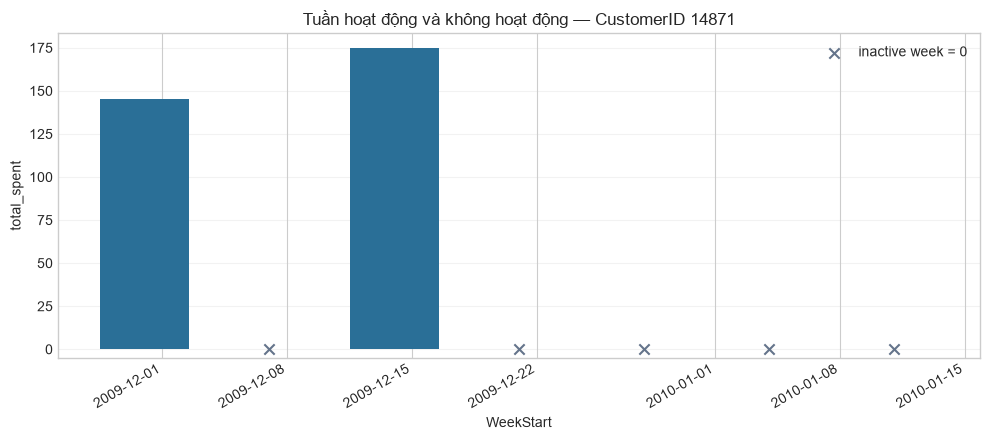

Đã lưu: C:\DATA\assign\A06\results\figures\customer_eda\inactive_week_example.png


In [ ]:
customer_span = customer_week_active.groupby("CustomerID", observed=True)[
    "WeekStart"
].agg(first_week="min", last_week="max", active_weeks="count")
customer_span["span_weeks"] = (
    customer_span["last_week"] - customer_span["first_week"]
).dt.days // 7 + 1
customer_span["inactive_weeks"] = (
    customer_span["span_weeks"] - customer_span["active_weeks"]
)

demo_candidates = customer_span.query("active_weeks >= 8 and inactive_weeks >= 3")
demo_customer = int(
    demo_candidates.sort_values(
        ["inactive_weeks", "active_weeks"], ascending=[False, False]
    ).index[0]
)

demo_active = customer_week_active.loc[
    customer_week_active["CustomerID"].eq(demo_customer)
].set_index("WeekStart")
demo_index = pd.date_range(
    demo_active.index.min(), demo_active.index.max(), freq="W-MON"
)
demo_timeline = demo_active.reindex(demo_index)
feature_columns = [
    "total_spent",
    "total_quantity",
    "order_count",
    "unique_products",
    "active_flag",
]
demo_timeline[feature_columns] = demo_timeline[feature_columns].fillna(0)
demo_timeline["CustomerID"] = demo_customer
demo_timeline.index.name = "WeekStart"

first_gap_position = np.flatnonzero(demo_timeline["active_flag"].eq(0).to_numpy())[0]
window_start = max(0, first_gap_position - 3)
demo_window = demo_timeline.iloc[window_start : first_gap_position + 6].copy()

print(f"Demo CustomerID: {demo_customer}")
display(demo_window[["CustomerID", *feature_columns]])

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = np.where(demo_window["active_flag"].eq(1), "#2A6F97", "#CBD5E1")
ax.bar(demo_window.index, demo_window["total_spent"], width=5, color=colors)
inactive_window = demo_window["active_flag"].eq(0)
ax.scatter(
    demo_window.index[inactive_window],
    np.zeros(inactive_window.sum()),
    marker="x",
    s=55,
    color="#64748B",
    label="inactive week = 0",
    clip_on=False,
    zorder=3,
)
ax.set(
    title=f"Tuần hoạt động và không hoạt động — CustomerID {demo_customer}",
    xlabel="WeekStart",
    ylabel="total_spent",
)
ax.grid(axis="y", alpha=0.25)
ax.set_ylim(bottom=-5)
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
output_path = FIGURE_DIR / "inactive_week_example.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Đã lưu: {output_path}")

Các cột hành vi của inactive week đều bằng 0. `CustomerID` vẫn được giữ để group/index sequence, nhưng sẽ **không** trở thành numerical input feature.

## 10. Target dự đoán tuần kế tiếp

Với target week $T$, input là 8 tuần ngay trước đó:

```text
[T-8, T-7, ..., T-1]  ──>  target tại T
```

- `target = 1`: khách hàng có ít nhất một purchase hợp lệ trong tuần $T$;
- `target = 0`: khách hàng không mua trong tuần $T$.

Target chỉ có hai trạng thái nên đây là **binary classification**. Không được đưa behavior của tuần $T$ vào 8 tuần features dùng để dự đoán chính tuần $T$.


## 11. Class distribution preview

Preview dưới đây chỉ ước lượng imbalance, chưa tạo tensor sequences. Quy ước prototype:

- loại hai boundary weeks không đầy đủ của workbook;
- timeline của mỗi khách hàng bắt đầu không sớm hơn purchase week đầu tiên;
- một target week chỉ hợp lệ sau khi đã có 8 tuần lịch sử;
- kéo timeline đến full week cuối để inactive periods sau lần mua cuối vẫn tạo negative targets.

Preview dùng toàn bộ thời gian **chỉ cho EDA**. Không dùng tỷ lệ này để tạo class weight; class weight production phải tính riêng từ train labels sau chronological split.


,count,percentage
target,,
0,328444,93.61
1,22420,6.39


Prototype samples: 350,864
Positive rate: 6.39%
Complete target-week range: 2009-12-07 -> 2011-11-28


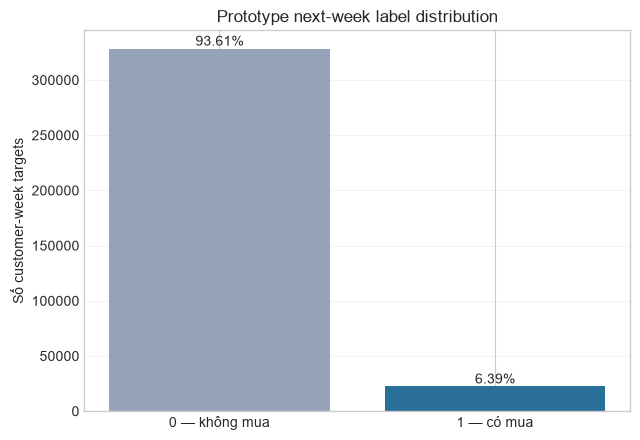

Đã lưu: C:\DATA\assign\A06\results\figures\customer_eda\prototype_label_balance.png


In [ ]:
first_observed_week = customer_week_active["WeekStart"].min()
last_observed_week = customer_week_active["WeekStart"].max()
first_full_week = first_observed_week + pd.Timedelta(weeks=1)
last_full_week = last_observed_week - pd.Timedelta(weeks=1)
complete_weeks = pd.date_range(first_full_week, last_full_week, freq="W-MON")

customer_ids = customer_week_active["CustomerID"].unique()
prototype_grid = pd.MultiIndex.from_product(
    [customer_ids, complete_weeks], names=["CustomerID", "WeekStart"]
).to_frame(index=False)

active_pairs = customer_week_active[["CustomerID", "WeekStart", "active_flag"]]
prototype_grid = prototype_grid.merge(
    active_pairs, on=["CustomerID", "WeekStart"], how="left"
)
prototype_grid["active_flag"] = prototype_grid["active_flag"].fillna(0).astype("int8")

customer_start = (
    customer_week_active.groupby("CustomerID", observed=True)["WeekStart"]
    .min()
    .clip(lower=first_full_week)
)
prototype_grid["timeline_start"] = prototype_grid["CustomerID"].map(customer_start)
eligible_target = prototype_grid["WeekStart"] >= prototype_grid[
    "timeline_start"
] + pd.Timedelta(weeks=8)
prototype_labels = prototype_grid.loc[eligible_target, "active_flag"]

label_distribution = (
    prototype_labels.value_counts()
    .reindex([0, 1], fill_value=0)
    .rename_axis("target")
    .to_frame("count")
)
label_distribution["percentage"] = (
    100 * label_distribution["count"] / len(prototype_labels)
)
display(label_distribution)
print(f"Prototype samples: {len(prototype_labels):,}")
print(f"Positive rate: {prototype_labels.mean():.2%}")
print(
    f"Complete target-week range: {first_full_week.date()} -> {last_full_week.date()}"
)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(
    ["0 — không mua", "1 — có mua"],
    label_distribution["count"],
    color=["#94A3B8", "#2A6F97"],
)
ax.set(
    title="Prototype next-week label distribution", ylabel="Số customer-week targets"
)
for bar, percentage in zip(bars, label_distribution["percentage"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.2f}%",
        ha="center",
        va="bottom",
    )
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
output_path = FIGURE_DIR / "prototype_label_balance.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Đã lưu: {output_path}")

del prototype_grid, prototype_labels
_ = gc.collect()

Preview cho thấy positive class chỉ khoảng **6,39%**, vì phần lớn customer-weeks không có purchase. Đây là dấu hiệu class imbalance đáng kể. Ở Prompt 5 cần khóa chính xác eligibility/window policy trước, split theo target week, rồi mới tính class weight bằng **train labels mà thôi**.
